# PSL Win Predictor — Exploratory Data Analysis

Covers the actual data science work: examining the raw PSL match data before modeling, and confirming the engineered features hold up before trusting them.

Dataset: 146 PSL matches (2016–2020). No toss data is present in this dataset -- confirmed by inspection, not assumed.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../src')

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

## 1. Load and inspect the raw data

In [3]:
df = pd.read_csv('../data/PSL_Match_Results.csv')
print(df.shape)
df.head()

(146, 10)


,Team 1,Ground,Margin,Year,Quarter,Month,Day,Scorecard,Team 2,Winner
0,Gladiators,Dubai (DSC),3 wickets,2016,Qtr 1,February,7,T20,Zalmi,Gladiators
1,Gladiators,Dubai (DSC),8 wickets,2016,Qtr 1,February,6,T20,Kings,Gladiators
2,Gladiators,Sharjah,8 wickets,2016,Qtr 1,February,14,T20,Zalmi,Zalmi
3,Kings,Dubai (DSC),5 wickets,2016,Qtr 1,February,17,T20,Zalmi,Zalmi
4,Kings,Dubai (DSC),7 wickets,2016,Qtr 1,February,5,T20,Qalandars,Kings


In [4]:
df.isnull().sum()

Team 1       0
Ground       0
Margin       7
Year         0
Quarter      0
Month        0
Day          0
Scorecard    0
Team 2       0
Winner       0
dtype: int64

## 2. Decisive vs undecided matches

7 matches have no clear winner (no result / tied / abandoned) -- these can't be a classification target and are dropped in `preprocess.py`.

In [5]:
df['Winner'].value_counts().tail(10)

Winner
Zalmi         31
Gladiators    30
United        28
Kings         22
Qalandars     15
Sultans       13
no result      3
tied           2
abandoned      2
Name: count, dtype: int64

## 3. Team win totals

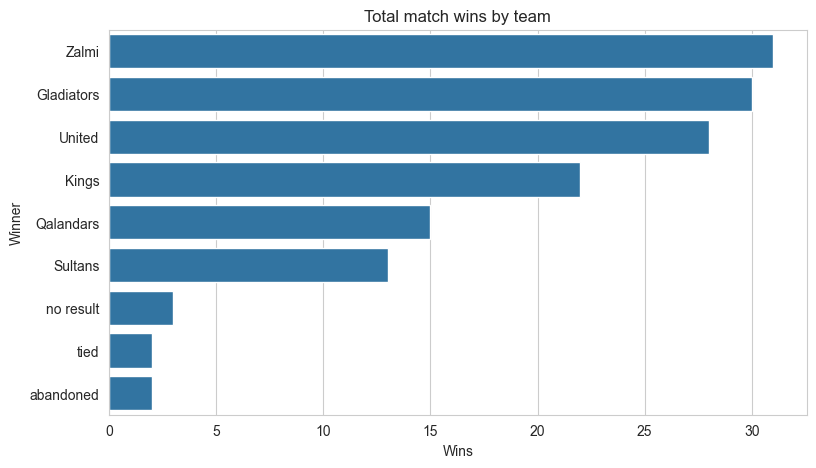

In [6]:
wins = df['Winner'].value_counts()
plt.figure(figsize=(9, 5))
sns.barplot(x=wins.values, y=wins.index, orient='h')
plt.title('Total match wins by team')
plt.xlabel('Wins')
plt.show()

## 4. Matches per ground

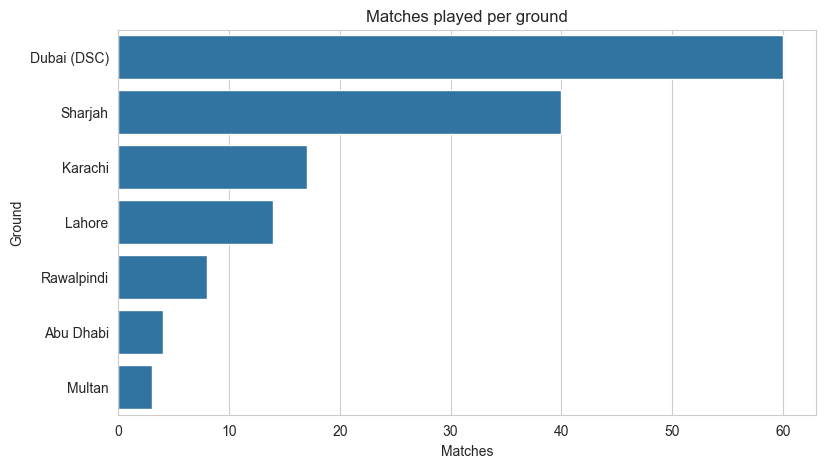

In [7]:
venue_matches = df['Ground'].value_counts()
plt.figure(figsize=(9, 5))
sns.barplot(x=venue_matches.values, y=venue_matches.index, orient='h')
plt.title('Matches played per ground')
plt.xlabel('Matches')
plt.show()

## 5. Engineered features — sanity check

Same features `preprocess.py` builds for the model: recent form (last 5 matches), head-to-head win rate, and venue win rate. No toss features -- the raw dataset doesn't include toss information.

In [8]:
from preprocess import build_features

feat_df, feature_cols = build_features('../data/PSL_Match_Results.csv')
feat_df[feature_cols + ['target']].describe()

Dropped 7 matches with no decisive result (no result / tied / abandoned).


,team1_form,team2_form,h2h_team1_win_rate,team1_venue_win_rate,team2_venue_win_rate,target
count,139.000000,139.000000,139.000000,139.000000,139.000000,139.000000
mean,0.502038,0.512950,0.480856,0.501904,0.528995,0.467626
std,0.242201,0.227975,0.272612,0.251233,0.260012,0.500755
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.400000,0.400000,0.333333,0.384615,0.424812,0.000000
50%,0.500000,0.600000,0.500000,0.500000,0.500000,0.000000
75%,0.600000,0.600000,0.600000,0.600000,0.666667,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


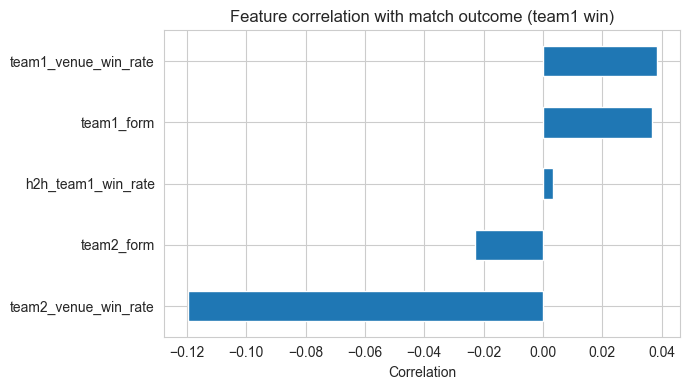

In [9]:
corr = feat_df[feature_cols + ['target']].corr()['target'].drop('target')
plt.figure(figsize=(7, 4))
corr.sort_values().plot(kind='barh')
plt.title('Feature correlation with match outcome (team1 win)')
plt.xlabel('Correlation')
plt.tight_layout()
plt.show()

## 6. Train the model

Actual training happens in `src/train_model.py`. Re-run here for a self-contained view.

In [10]:
%cd ../src
%run train_model.py
%cd ../notebooks

C:\Users\DELL\psl-win-predictor\src
Dropped 7 matches with no decisive result (no result / tied / abandoned).
Training on 139 matches, 5 features.
Test set size will be ~27 matches — small, so treat accuracy as directional, not a precise figure.


logistic_regression — accuracy: 0.607
              precision    recall  f1-score   support

  Team2 wins       0.61      0.73      0.67        15
  Team1 wins       0.60      0.46      0.52        13

    accuracy                           0.61        28
   macro avg       0.61      0.60      0.59        28
weighted avg       0.61      0.61      0.60        28


decision_tree — accuracy: 0.321
              precision    recall  f1-score   support

  Team2 wins       0.17      0.07      0.10        15
  Team1 wins       0.36      0.62      0.46        13

    accuracy                           0.32        28
   macro avg       0.27      0.34      0.28        28
weighted avg       0.26      0.32      0.26        28


Best model: logistic_regre

## Notes

- Dataset covers 2016-2020 only (146 matches, 139 usable after dropping undecided results).
- No toss information is available in this dataset.
- Logistic Regression (60.7% accuracy) outperformed a Decision Tree (32.1%) here -- with only 139 matches, the simpler model generalizes better; the tree overfits.
- This does not account for player injuries, current squad changes, or seasons after 2020.